11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 53s 59ms/step - accuracy: 0.9434 - loss: 0.1897 - val_accuracy: 0.9838 - val_loss: 0.0529
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - accuracy: 0.9841 - loss: 0.0539 - val_accuracy: 0.9875 - val_loss: 0.0415
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 57ms/step - accuracy: 0.9878 - loss: 0.0380 - val_accuracy: 0.9912 - val_loss: 0.0364
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - accuracy: 0.9919 - loss: 0.0271 - val_accuracy: 0.9888 - val_loss: 0.0430
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 58ms/step - accuracy: 0.9931 - loss: 0.0215 - val_accuracy: 0.9880 - val_loss: 0.0411
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - accuracy: 0.9941 - loss: 0.0176 - val_accuracy: 0.9878 - val_loss: 0.0480
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.9954 - loss: 0.0136 - val_accuracy: 0.9895 - val_loss: 0.0415
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.9962 - loss: 0.0117 - 

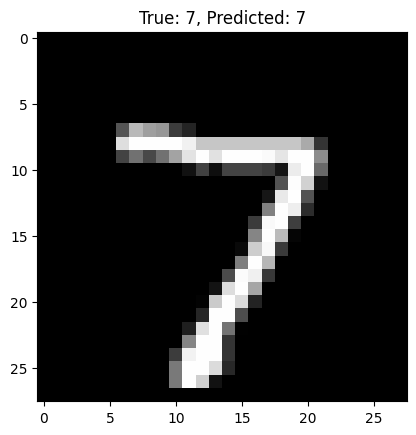

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
True label: cat
Predicted label: cat


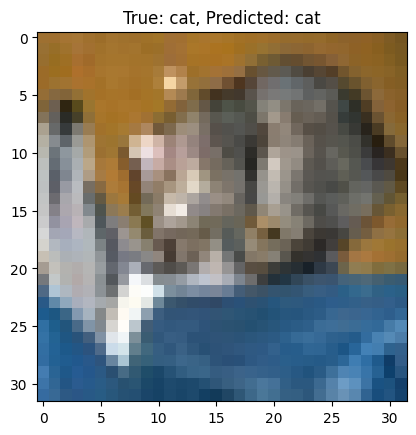

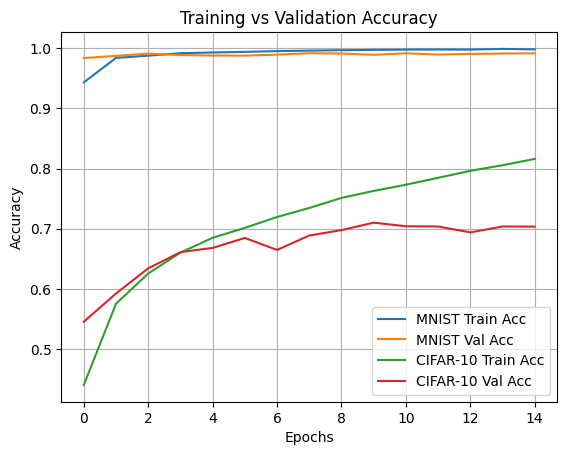

In [ ]:
# ============================
# Import Required Libraries
# ============================
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


# ============================
# Load Datasets
# ============================
# MNIST: Handwritten digits (28x28, grayscale)
(mnist_X_train, mnist_y_train), (mnist_X_test, mnist_y_test) = datasets.mnist.load_data()

# CIFAR-10: Color images (32x32, RGB)
(cifar_X_train, cifar_y_train), (cifar_X_test, cifar_y_test) = datasets.cifar10.load_data()


# ============================
# Preprocessing MNIST
# ============================
# Reshape to add channel dimension (for CNN)
mnist_X_train = mnist_X_train.reshape(-1, 28, 28, 1) / 255.0
mnist_X_test = mnist_X_test.reshape(-1, 28, 28, 1) / 255.0

# Convert labels to categorical (one-hot encoding)
mnist_y_train = tf.keras.utils.to_categorical(mnist_y_train, 10)
mnist_y_test = tf.keras.utils.to_categorical(mnist_y_test, 10)


# ============================
# Preprocessing CIFAR-10
# ============================
# Normalize pixel values
cifar_X_train = cifar_X_train / 255.0
cifar_X_test = cifar_X_test / 255.0

# Convert labels to categorical
cifar_y_train = tf.keras.utils.to_categorical(cifar_y_train, 10)
cifar_y_test = tf.keras.utils.to_categorical(cifar_y_test, 10)


# ============================
# Define CNN Model (2 Conv Layers)
# ============================
def build_cnn(input_shape):
    model = models.Sequential()

    # First Convolution Layer
    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape))

    # MaxPooling Layer (reduces size)
    model.add(layers.MaxPooling2D((2,2)))

    # Second Convolution Layer
    model.add(layers.Conv2D(64, (3,3), activation='relu'))

    # MaxPooling Layer
    model.add(layers.MaxPooling2D((2,2)))

    # Flatten to convert 2D to 1D
    model.add(layers.Flatten())

    # Fully Connected Layer
    model.add(layers.Dense(64, activation='relu'))

    # Output Layer (10 classes)
    model.add(layers.Dense(10, activation='softmax'))

    return model


# ============================
# Build and Compile MNIST Model
# ============================
mnist_model = build_cnn((28, 28, 1))

# Compile model with optimizer, loss, and accuracy metric
mnist_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])


# ============================
# Train MNIST Model
# ============================
mnist_history = mnist_model.fit(
    mnist_X_train, mnist_y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)


# ============================
# Build and Compile CIFAR-10 Model
# ============================
cifar_model = build_cnn((32, 32, 3))

cifar_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])


# ============================
# Train CIFAR-10 Model
# ============================
cifar_history = cifar_model.fit(
    cifar_X_train, cifar_y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)


# ============================
# Evaluate Models
# ============================
mnist_test_loss, mnist_test_acc = mnist_model.evaluate(mnist_X_test, mnist_y_test)
cifar_test_loss, cifar_test_acc = cifar_model.evaluate(cifar_X_test, cifar_y_test)

print("MNIST Test Accuracy:", mnist_test_acc)
print("CIFAR-10 Test Accuracy:", cifar_test_acc)


# ============================
# MNIST Prediction (Single Image)
# ============================
image_index_mnist = 0

test_image_mnist = mnist_X_test[image_index_mnist]
true_label_mnist = np.argmax(mnist_y_test[image_index_mnist])

# Add batch dimension
test_image_input_mnist = np.expand_dims(test_image_mnist, axis=0)

# Predict
predictions_mnist = mnist_model.predict(test_image_input_mnist)
predicted_label_mnist = np.argmax(predictions_mnist[0])

print(f"True label (MNIST): {true_label_mnist}")
print(f"Predicted label (MNIST): {predicted_label_mnist}")

# Show image
plt.imshow(test_image_mnist.squeeze(), cmap='gray')
plt.title(f"True: {true_label_mnist}, Predicted: {predicted_label_mnist}")
plt.show()


# ============================
# CIFAR-10 Prediction (Single Image)
# ============================
image_index = 0

test_image = cifar_X_test[image_index]
true_label = np.argmax(cifar_y_test[image_index])

# Add batch dimension
test_image_input = np.expand_dims(test_image, axis=0)

# Predict
predictions = cifar_model.predict(test_image_input)
predicted_label = np.argmax(predictions[0])

# Class names
cifar10_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                       'dog', 'frog', 'horse', 'ship', 'truck']

print(f"True label: {cifar10_class_names[true_label]}")
print(f"Predicted label: {cifar10_class_names[predicted_label]}")

# Show image# ============================
# Import Required Libraries
# ============================
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


# ============================
# Load Datasets
# ============================
# MNIST: Handwritten digits (28x28, grayscale)
(mnist_X_train, mnist_y_train), (mnist_X_test, mnist_y_test) = datasets.mnist.load_data()

# CIFAR-10: Color images (32x32, RGB)
(cifar_X_train, cifar_y_train), (cifar_X_test, cifar_y_test) = datasets.cifar10.load_data()


# ============================
# Preprocessing MNIST
# ============================
# Reshape to add channel dimension (for CNN)
mnist_X_train = mnist_X_train.reshape(-1, 28, 28, 1) / 255.0
mnist_X_test = mnist_X_test.reshape(-1, 28, 28, 1) / 255.0

# Convert labels to categorical (one-hot encoding)
mnist_y_train = tf.keras.utils.to_categorical(mnist_y_train, 10)
mnist_y_test = tf.keras.utils.to_categorical(mnist_y_test, 10)


# ============================
# Preprocessing CIFAR-10
# ============================
# Normalize pixel values
cifar_X_train = cifar_X_train / 255.0
cifar_X_test = cifar_X_test / 255.0

# Convert labels to categorical
cifar_y_train = tf.keras.utils.to_categorical(cifar_y_train, 10)
cifar_y_test = tf.keras.utils.to_categorical(cifar_y_test, 10)


# ============================
# Define CNN Model (2 Conv Layers)
# ============================
def build_cnn(input_shape):
    model = models.Sequential()

    # First Convolution Layer
    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape))

    # MaxPooling Layer (reduces size)
    model.add(layers.MaxPooling2D((2,2)))

    # Second Convolution Layer
    model.add(layers.Conv2D(64, (3,3), activation='relu'))

    # MaxPooling Layer
    model.add(layers.MaxPooling2D((2,2)))

    # Flatten to convert 2D to 1D
    model.add(layers.Flatten())

    # Fully Connected Layer
    model.add(layers.Dense(64, activation='relu'))

    # Output Layer (10 classes)
    model.add(layers.Dense(10, activation='softmax'))

    return model


# ============================
# Build and Compile MNIST Model
# ============================
mnist_model = build_cnn((28, 28, 1))

# Compile model with optimizer, loss, and accuracy metric
mnist_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])


# ============================
# Train MNIST Model
# ============================
mnist_history = mnist_model.fit(
    mnist_X_train, mnist_y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)


# ============================
# Build and Compile CIFAR-10 Model
# ============================
cifar_model = build_cnn((32, 32, 3))

cifar_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])


# ============================
# Train CIFAR-10 Model
# ============================
cifar_history = cifar_model.fit(
    cifar_X_train, cifar_y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)


# ============================
# Evaluate Models
# ============================
mnist_test_loss, mnist_test_acc = mnist_model.evaluate(mnist_X_test, mnist_y_test)
cifar_test_loss, cifar_test_acc = cifar_model.evaluate(cifar_X_test, cifar_y_test)

print("MNIST Test Accuracy:", mnist_test_acc)
print("CIFAR-10 Test Accuracy:", cifar_test_acc)


# ============================
# MNIST Prediction (Single Image)
# ============================
image_index_mnist = 0

test_image_mnist = mnist_X_test[image_index_mnist]
true_label_mnist = np.argmax(mnist_y_test[image_index_mnist])

# Add batch dimension
test_image_input_mnist = np.expand_dims(test_image_mnist, axis=0)

# Predict
predictions_mnist = mnist_model.predict(test_image_input_mnist)
predicted_label_mnist = np.argmax(predictions_mnist[0])

print(f"True label (MNIST): {true_label_mnist}")
print(f"Predicted label (MNIST): {predicted_label_mnist}")

# Show image
plt.imshow(test_image_mnist.squeeze(), cmap='gray')
plt.title(f"True: {true_label_mnist}, Predicted: {predicted_label_mnist}")
plt.show()


# ============================
# CIFAR-10 Prediction (Single Image)
# ============================
image_index = 0

test_image = cifar_X_test[image_index]
true_label = np.argmax(cifar_y_test[image_index])

# Add batch dimension
test_image_input = np.expand_dims(test_image, axis=0)

# Predict
predictions = cifar_model.predict(test_image_input)
predicted_label = np.argmax(predictions[0])

# Class names
cifar10_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                       'dog', 'frog', 'horse', 'ship', 'truck']

print(f"True label: {cifar10_class_names[true_label]}")
print(f"Predicted label: {cifar10_class_names[predicted_label]}")

# Show image
plt.imshow(test_image)
plt.title(f"True: {cifar10_class_names[true_label]}, Predicted: {cifar10_class_names[predicted_label]}")
plt.show()


# ============================
# Plot Accuracy Graph
# ============================
plt.plot(mnist_history.history['accuracy'], label='MNIST Train Acc')
plt.plot(mnist_history.history['val_accuracy'], label='MNIST Val Acc')

plt.plot(cifar_history.history['accuracy'], label='CIFAR-10 Train Acc')
plt.plot(cifar_history.history['val_accuracy'], label='CIFAR-10 Val Acc')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()

# Save graph
plt.savefig('2-layer CNN.png')

plt.show()
plt.imshow(test_image)
plt.title(f"True: {cifar10_class_names[true_label]}, Predicted: {cifar10_class_names[predicted_label]}")
plt.show()


# ============================
# Plot Accuracy Graph
# ============================
plt.plot(mnist_history.history['accuracy'], label='MNIST Train Acc')
plt.plot(mnist_history.history['val_accuracy'], label='MNIST Val Acc')

plt.plot(cifar_history.history['accuracy'], label='CIFAR-10 Train Acc')
plt.plot(cifar_history.history['val_accuracy'], label='CIFAR-10 Val Acc')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()

# Save graph
plt.savefig('2-layer CNN.png')

plt.show()